importing the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Readind the files (a -application_data.csv and p - previous_application )

In [2]:
a = pd.read_csv(r"C:\Users\User\Downloads\application_data.csv")
p = pd.read_csv(r"C:\Users\User\Downloads\previous_application.csv")

Checking for the null values by percentage

In [3]:
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
((a.isnull().sum()/len(a))*100).round(2)

SK_ID_CURR                       0.00
TARGET                           0.00
NAME_CONTRACT_TYPE               0.00
CODE_GENDER                      0.00
FLAG_OWN_CAR                     0.00
FLAG_OWN_REALTY                  0.00
CNT_CHILDREN                     0.00
AMT_INCOME_TOTAL                 0.00
AMT_CREDIT                       0.00
AMT_ANNUITY                      0.00
AMT_GOODS_PRICE                  0.09
NAME_TYPE_SUITE                  0.42
NAME_INCOME_TYPE                 0.00
NAME_EDUCATION_TYPE              0.00
NAME_FAMILY_STATUS               0.00
NAME_HOUSING_TYPE                0.00
REGION_POPULATION_RELATIVE       0.00
DAYS_BIRTH                       0.00
DAYS_EMPLOYED                    0.00
DAYS_REGISTRATION                0.00
DAYS_ID_PUBLISH                  0.00
OWN_CAR_AGE                     65.99
FLAG_MOBIL                       0.00
FLAG_EMP_PHONE                   0.00
FLAG_WORK_PHONE                  0.00
FLAG_CONT_MOBILE                 0.00
FLAG_PHONE  

In [4]:
((p.isnull().sum()/len(p))*100).round(2)

SK_ID_PREV                      0.00
SK_ID_CURR                      0.00
NAME_CONTRACT_TYPE              0.00
AMT_ANNUITY                    22.29
AMT_APPLICATION                 0.00
AMT_CREDIT                      0.00
AMT_DOWN_PAYMENT               53.64
AMT_GOODS_PRICE                23.08
WEEKDAY_APPR_PROCESS_START      0.00
HOUR_APPR_PROCESS_START         0.00
FLAG_LAST_APPL_PER_CONTRACT     0.00
NFLAG_LAST_APPL_IN_DAY          0.00
RATE_DOWN_PAYMENT              53.64
RATE_INTEREST_PRIMARY          99.64
RATE_INTEREST_PRIVILEGED       99.64
NAME_CASH_LOAN_PURPOSE          0.00
NAME_CONTRACT_STATUS            0.00
DAYS_DECISION                   0.00
NAME_PAYMENT_TYPE               0.00
CODE_REJECT_REASON              0.00
NAME_TYPE_SUITE                49.12
NAME_CLIENT_TYPE                0.00
NAME_GOODS_CATEGORY             0.00
NAME_PORTFOLIO                  0.00
NAME_PRODUCT_TYPE               0.00
CHANNEL_TYPE                    0.00
SELLERPLACE_AREA                0.00
N

Now i am gonna remove the columns which has the null values more then 45 percentage we don't have any ues of that columns because it having half of the null values with it

In [5]:
a.shape

(307511, 122)

In [6]:
#This code removes columns from dataframe a that have 45% or more missing (NaN) values
a = a.loc[:, a.isnull().mean() < 0.45]

In [7]:
a.shape
#It has removed more then 40 columns

(307511, 73)

Same for p dataframe also

In [8]:
p.shape

(1670214, 37)

In [9]:
p = p.loc[:, p.isnull().mean() < 0.45]

In [10]:
p.shape
#It only have 5 columns null values more then 45%

(1670214, 32)

Checking for the null values again this time i gonna handle the rest of the dataframe

In [11]:
((a.isnull().sum()/len(a))*100).round(2),((p.isnull().sum()/len(p))*100).round(2)

(SK_ID_CURR                      0.00
 TARGET                          0.00
 NAME_CONTRACT_TYPE              0.00
 CODE_GENDER                     0.00
 FLAG_OWN_CAR                    0.00
 FLAG_OWN_REALTY                 0.00
 CNT_CHILDREN                    0.00
 AMT_INCOME_TOTAL                0.00
 AMT_CREDIT                      0.00
 AMT_ANNUITY                     0.00
 AMT_GOODS_PRICE                 0.09
 NAME_TYPE_SUITE                 0.42
 NAME_INCOME_TYPE                0.00
 NAME_EDUCATION_TYPE             0.00
 NAME_FAMILY_STATUS              0.00
 NAME_HOUSING_TYPE               0.00
 REGION_POPULATION_RELATIVE      0.00
 DAYS_BIRTH                      0.00
 DAYS_EMPLOYED                   0.00
 DAYS_REGISTRATION               0.00
 DAYS_ID_PUBLISH                 0.00
 FLAG_MOBIL                      0.00
 FLAG_EMP_PHONE                  0.00
 FLAG_WORK_PHONE                 0.00
 FLAG_CONT_MOBILE                0.00
 FLAG_PHONE                      0.00
 FLAG_EMAIL 

First i am gonna handle the numerical columns

Using the variable to make change is always safe if anything goes worng it did not affect the original dataframe we can check the result and then implement the rest to the dataframe

In [12]:
# why median because the mean will affected by the "nan" values that's why filling nan values with median
num_cols_a = a.select_dtypes(include='number').columns
a[num_cols_a] = a[num_cols_a].fillna(a[num_cols_a].median())

In [13]:
num_cols_p = p.select_dtypes(include='number').columns
p[num_cols_p] = p[num_cols_p].fillna(p[num_cols_p].median())

Now categorical columns

In [14]:
# For categorical variable we use mode
cat_cols_a = a.select_dtypes(exclude='number').columns
for col in cat_cols_a:
    a[col] = a[col].fillna(a[col].mode()[0])

In [15]:
cat_cols_p = p.select_dtypes(exclude='number').columns
for col in cat_cols_p:
    p[col] = p[col].fillna(p[col].mode()[0])

In [16]:
#It simply returns the total number of missing (NaN) values in dataframe a and in dataframe p
a.isnull().sum().sum(),p.isnull().sum().sum()

(0, 0)

Now the null values are handled now we can start the analyst

In [17]:
#It checks every numeric column in a and counts how many values are outliers using the IQR rule and stores the counts in outlier_summary
num_cols = a.select_dtypes(include='number').columns

outlier_summary = {}

for col in num_cols:
    Q1 = a[col].quantile(0.25)
    Q3 = a[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = a[(a[col] < lower) | (a[col] > upper)]
    outlier_summary[col] = len(outliers)

outlier_summary


{'SK_ID_CURR': 0,
 'TARGET': 24825,
 'CNT_CHILDREN': 4272,
 'AMT_INCOME_TOTAL': 14035,
 'AMT_CREDIT': 6562,
 'AMT_ANNUITY': 7504,
 'AMT_GOODS_PRICE': 14728,
 'REGION_POPULATION_RELATIVE': 8412,
 'DAYS_BIRTH': 0,
 'DAYS_EMPLOYED': 72217,
 'DAYS_REGISTRATION': 659,
 'DAYS_ID_PUBLISH': 0,
 'FLAG_MOBIL': 1,
 'FLAG_EMP_PHONE': 55386,
 'FLAG_WORK_PHONE': 61308,
 'FLAG_CONT_MOBILE': 574,
 'FLAG_PHONE': 0,
 'FLAG_EMAIL': 17442,
 'CNT_FAM_MEMBERS': 4007,
 'REGION_RATING_CLIENT': 80527,
 'REGION_RATING_CLIENT_W_CITY': 78027,
 'HOUR_APPR_PROCESS_START': 2257,
 'REG_REGION_NOT_LIVE_REGION': 4657,
 'REG_REGION_NOT_WORK_REGION': 15612,
 'LIVE_REGION_NOT_WORK_REGION': 12503,
 'REG_CITY_NOT_LIVE_CITY': 24039,
 'REG_CITY_NOT_WORK_CITY': 70867,
 'LIVE_CITY_NOT_WORK_CITY': 55215,
 'EXT_SOURCE_2': 0,
 'EXT_SOURCE_3': 4313,
 'OBS_30_CNT_SOCIAL_CIRCLE': 19971,
 'DEF_30_CNT_SOCIAL_CIRCLE': 35166,
 'OBS_60_CNT_SOCIAL_CIRCLE': 19564,
 'DEF_60_CNT_SOCIAL_CIRCLE': 25769,
 'DAYS_LAST_PHONE_CHANGE': 435,
 'FLAG_DO

In [18]:
outlier_summary_p = {}

for col in num_cols_p:
    Q1 = p[col].quantile(0.25)
    Q3 = p[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = p[(p[col] < lower) | (p[col] > upper)]
    outlier_summary_p[col] = len(outliers)

outlier_summary_p


{'SK_ID_PREV': 0,
 'SK_ID_CURR': 0,
 'AMT_ANNUITY': 162620,
 'AMT_APPLICATION': 208019,
 'AMT_CREDIT': 179989,
 'AMT_GOODS_PRICE': 236035,
 'HOUR_APPR_PROCESS_START': 1639,
 'NFLAG_LAST_APPL_IN_DAY': 5900,
 'DAYS_DECISION': 17571,
 'SELLERPLACE_AREA': 268087,
 'CNT_PAYMENT': 344916,
 'DAYS_FIRST_DRAWING': 62705,
 'DAYS_FIRST_DUE': 374760,
 'DAYS_LAST_DUE_1ST_VERSION': 431364,
 'DAYS_LAST_DUE': 468436,
 'DAYS_TERMINATION': 482992,
 'NFLAG_INSURED_ON_APPROVAL': 331622}

Now i am gonna visualize the "Outliers in AMT_CREDIT"

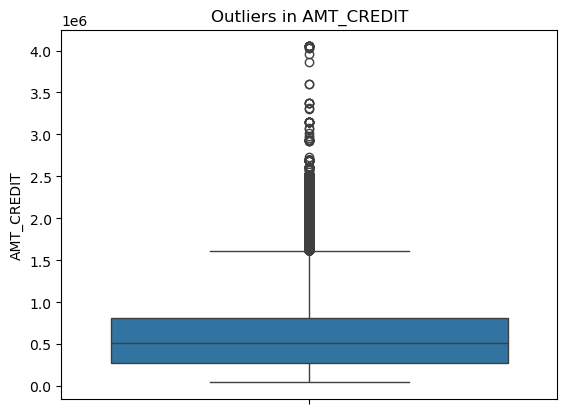

In [19]:
sns.boxplot(y=a['AMT_CREDIT'])
plt.title("Outliers in AMT_CREDIT")
plt.show()

"Outliers in AMT_CREDIT" it only have the Q1,Q2,Q3 between the 0.3 to 0.8 something like that we can see clearly some outliers in the boxplot

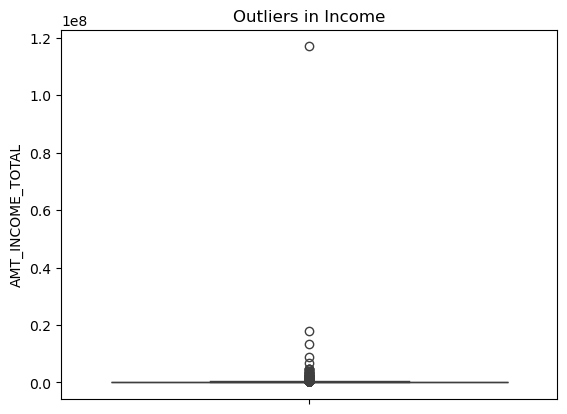

In [20]:
sns.boxplot(y=a['AMT_INCOME_TOTAL'])
plt.title("Outliers in Income")
plt.show()

#We identified outliers using the Interquartile Range (IQR) method.
## Outliers were mainly observed in income, credit amount and annuity values.
## These represent customers taking unusually large loans or having very high income.
## Since these cases are real business scenarios and may indicate risk behavior, we did not remove them, but we flagged them for further analysis.

Now i am gonna check for the imbalance of the 'TARGET' data

In [21]:
a['TARGET'].value_counts(normalize=True) * 100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

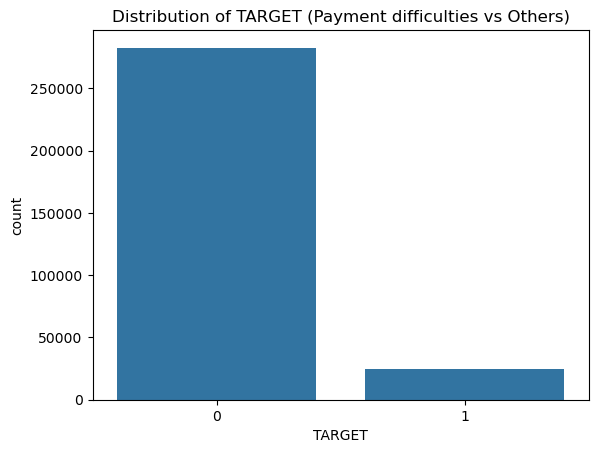

In [22]:
sns.countplot(x='TARGET', data=a)
plt.title("Distribution of TARGET (Payment difficulties vs Others)")
plt.show()

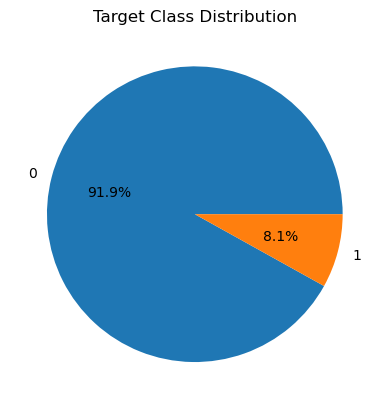

In [23]:
a['TARGET'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Target Class Distribution")
plt.ylabel("")
plt.show()

The dataset is highly imbalanced.
Around ~90% of customers do not default (TARGET = 0), while only ~10% experience payment difficulties (TARGET = 1).
Because of this imbalance, analyses and visualizations are interpreted mainly using percentages rather than raw counts.

I am gonna start with important numeric features:
->Income
->Credit amount
->Annuity

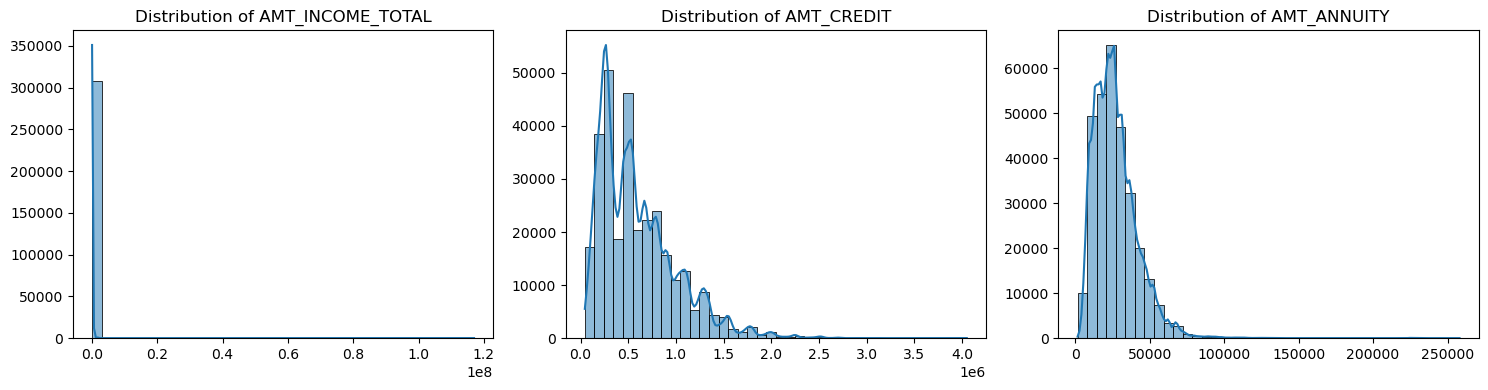

In [24]:
cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']

plt.figure(figsize=(15,4))

for i, c in enumerate(cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(a[c], bins=40, kde=True)
    plt.title(f"Distribution of {c}")
    plt.xlabel("")
    plt.ylabel("")

plt.tight_layout()
plt.show()

In [ ]:
num_cols = p.select_dtypes(include='number').columns
plt.figure(figsize=(18,8))

for i, c in enumerate(num_cols[:6], 1):
    plt.subplot(2, 3, i)   # 2 rows, 3 columns of plots
    sns.histplot(p[c], bins=40, kde=True)
    plt.title(f"Distribution of {c}")
    plt.xlabel("")
    plt.ylabel("")

plt.tight_layout()
plt.show()

#### Income and credit variables are right-skewed, showing that most clients take smaller loans, while a few take very large amounts.

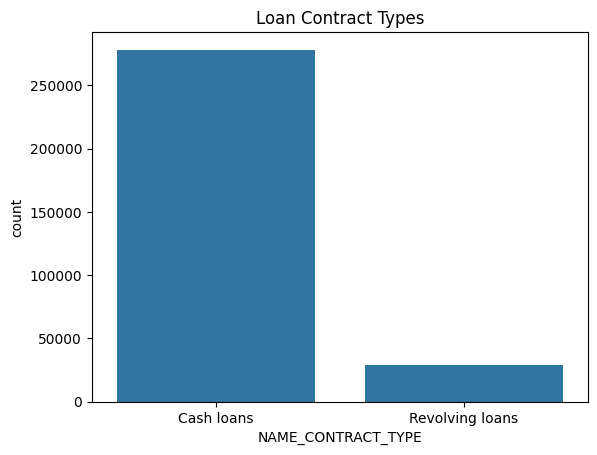

In [25]:
sns.countplot(x='NAME_CONTRACT_TYPE', data=a)
plt.title("Loan Contract Types")
plt.show()

In [47]:
p['NAME_CONTRACT_TYPE'].value_counts(normalize=True) * 100

,proportion
NAME_CONTRACT_TYPE,
Cash loans,44.757917
Consumer loans,43.656142
Revolving loans,11.565225
XNA,0.020716


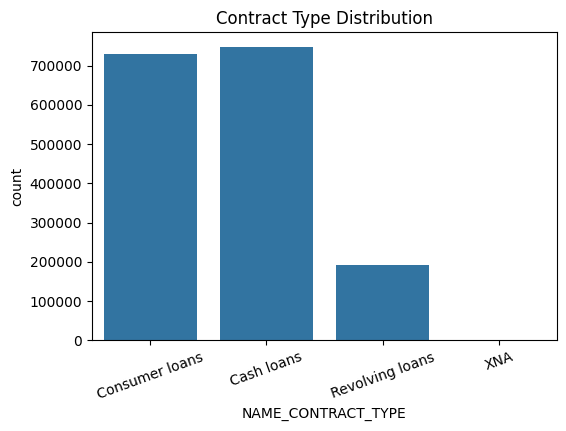

In [48]:
plt.figure(figsize=(6,4))
sns.countplot(x='NAME_CONTRACT_TYPE', data=p)
plt.title("Contract Type Distribution")
plt.xticks(rotation=20)
plt.show()


In [49]:
p['NAME_CASH_LOAN_PURPOSE'].value_counts().head(10)


,count
NAME_CASH_LOAN_PURPOSE,
XAP,922661
XNA,677918
Repairs,23765
Other,15608
Urgent needs,8412
Buying a used car,2888
Building a house or an annex,2693
Everyday expenses,2416
Medicine,2174


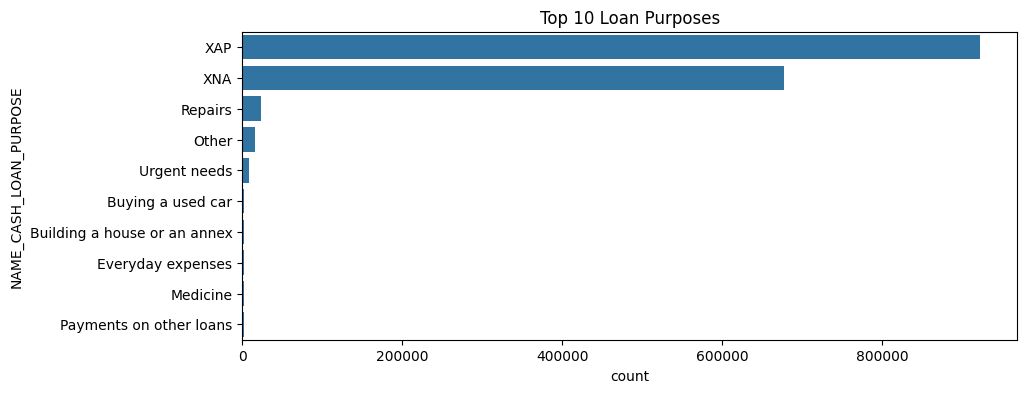

In [50]:
plt.figure(figsize=(10,4))
sns.countplot(
    y=p['NAME_CASH_LOAN_PURPOSE'],
    order=p['NAME_CASH_LOAN_PURPOSE'].value_counts().head(10).index
)
plt.title("Top 10 Loan Purposes")
plt.show()


In [55]:
print(p['CHANNEL_TYPE'].value_counts())
print(p['PRODUCT_COMBINATION'].value_counts().head(10))

CHANNEL_TYPE
Credit and cash offices       719968
Country-wide                  494690
Stone                         212083
Regional / Local              108528
Contact center                 71297
AP+ (Cash loan)                57046
Channel of corporate sales      6150
Car dealer                       452
Name: count, dtype: int64
PRODUCT_COMBINATION
Cash                              286336
POS household with interest       263622
POS mobile with interest          220670
Cash X-Sell: middle               143883
Cash X-Sell: low                  130248
Card Street                       112582
POS industry with interest         98833
POS household without interest     82908
Card X-Sell                        80582
Cash Street: high                  59639
Name: count, dtype: int64


####Most loans are cash loans; a smaller proportion are revolving loans.

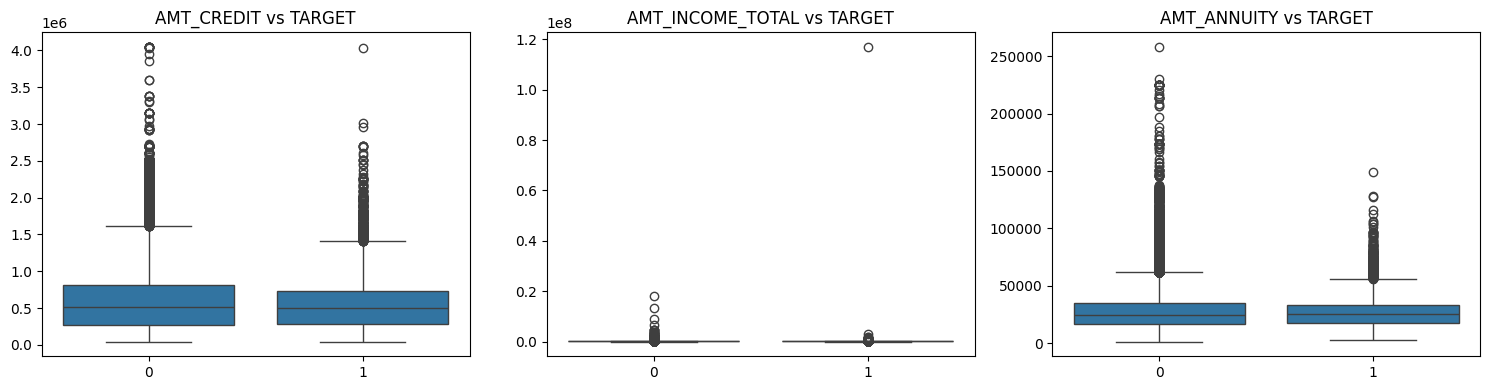

In [26]:
cols = ['AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY']

plt.figure(figsize=(15,4))

for i, c in enumerate(cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x='TARGET', y=c, data=a)
    plt.title(f"{c} vs TARGET")
    plt.xlabel("")
    plt.ylabel("")

plt.tight_layout()
plt.show()


clients with TARGET=1 often have:
lower incomes
relatively higher credit amounts
annuities that strain repayment capacity

# Clients who default tend to have higher loan amounts relative to their income, indicating affordability pressure.

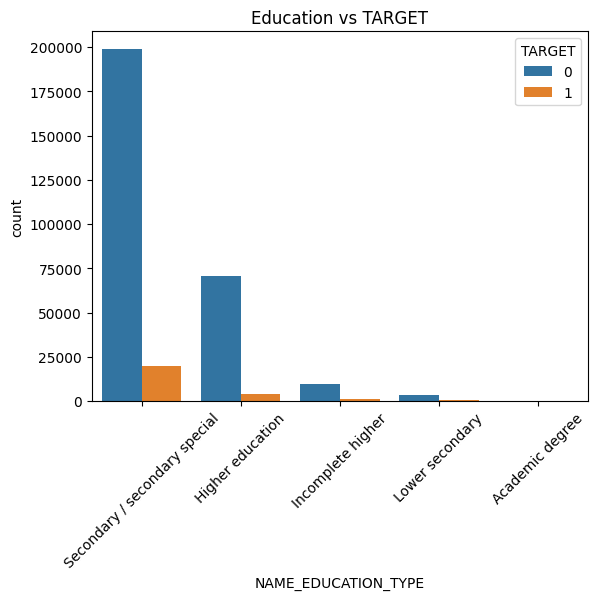

In [27]:
sns.countplot(x='NAME_EDUCATION_TYPE', hue='TARGET', data=a)
plt.xticks(rotation=45)
plt.title("Education vs TARGET")
plt.show()

###more defaults maybe in lower education categories

###fewer in higher education segments

###Education level shows differences in default risk, possibly due to income stability.

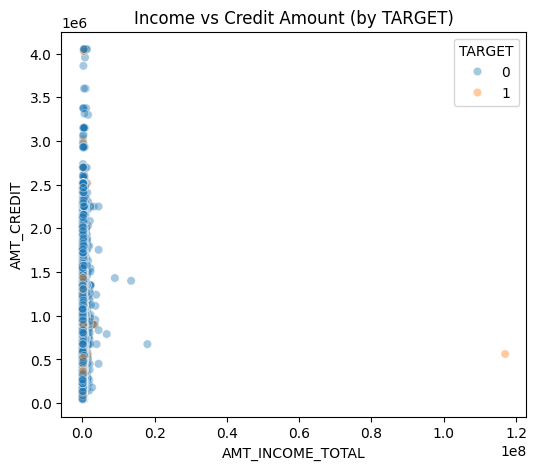

In [28]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x='AMT_INCOME_TOTAL',
    y='AMT_CREDIT',
    hue='TARGET',
    data=a,
    alpha=0.4
)
plt.title("Income vs Credit Amount (by TARGET)")
plt.show()


###People taking high credit amounts relative to income appear more frequently among defaulters.
###This indicates affordability pressure as a key risk factor.

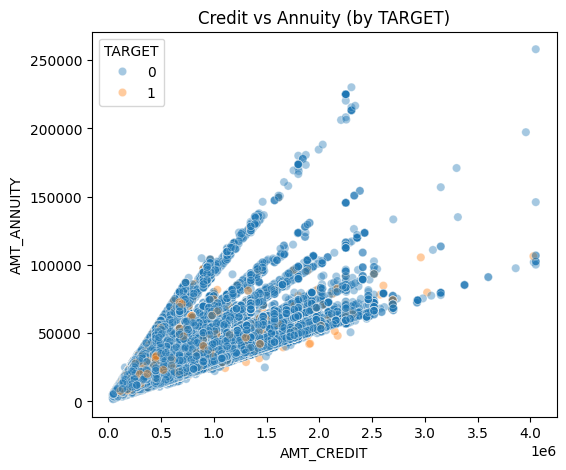

In [29]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x='AMT_CREDIT',
    y='AMT_ANNUITY',
    hue='TARGET',
    data=a,
    alpha=0.4
)
plt.title("Credit vs Annuity (by TARGET)")
plt.show()

###Higher credit values naturally lead to higher annuity obligations.
###Defaulters appear more concentrated in high-annuity ranges.

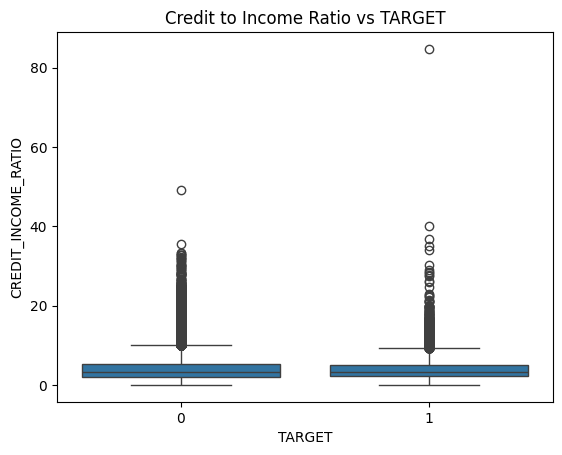

In [30]:
a['CREDIT_INCOME_RATIO'] = a['AMT_CREDIT'] / a['AMT_INCOME_TOTAL']

sns.boxplot(x='TARGET', y='CREDIT_INCOME_RATIO', data=a)
plt.title("Credit to Income Ratio vs TARGET")
plt.show()

####Clients whose loan size is very high compared to their income show more payment difficulties.
####This ratio is one of the most important business insights.

####Bivariate analysis revealed strong financial behavior patterns.
####Clients with payment difficulties typically had higher credit-to-income ratios and larger annuities relative to loan size.
####These findings indicate repayment stress as a key driver of default.

different variables relate to each other differently for
(1) clients with payment difficulties vs
(0) all other clients?”

In [31]:
d1 = a[a['TARGET'] == 1]
d0 = a[a['TARGET'] == 0]

In [32]:
corr1 = d1.select_dtypes(include='number').corr().abs()
corr0 = d0.select_dtypes(include='number').corr().abs()

In [33]:
def top_corr_pairs(corr_matrix, n=10):
    # convert matrix → pairs
    corr_pairs = corr_matrix.abs().unstack()

    # drop self correlations
    corr_pairs = corr_pairs[corr_pairs < 1]

    # remove duplicate pairs (keep only Var1 < Var2)
    corr_pairs = corr_pairs.reset_index()
    corr_pairs.columns = ['Var1', 'Var2', 'Correlation']
    corr_pairs = corr_pairs[corr_pairs['Var1'] < corr_pairs['Var2']]

    # sort and return
    return corr_pairs.sort_values(by='Correlation', ascending=False).head(n)

# (ignoring self-correlations like Var1–Var1) Helper function

In [34]:
top10_d1 = top_corr_pairs(corr1, 10)
top10_d0 = top_corr_pairs(corr0, 10)

In [35]:
top10_d1, top10_d0

(                             Var1                         Var2  Correlation
 458                 DAYS_EMPLOYED               FLAG_EMP_PHONE     0.999702
 1597     OBS_30_CNT_SOCIAL_CIRCLE     OBS_60_CNT_SOCIAL_CIRCLE     0.998270
 172                    AMT_CREDIT              AMT_GOODS_PRICE     0.982783
 969          REGION_RATING_CLIENT  REGION_RATING_CLIENT_W_CITY     0.956637
 71                   CNT_CHILDREN              CNT_FAM_MEMBERS     0.885484
 1654     DEF_30_CNT_SOCIAL_CIRCLE     DEF_60_CNT_SOCIAL_CIRCLE     0.869016
 1253  LIVE_REGION_NOT_WORK_REGION   REG_REGION_NOT_WORK_REGION     0.847885
 1424      LIVE_CITY_NOT_WORK_CITY       REG_CITY_NOT_WORK_CITY     0.778540
 228                   AMT_ANNUITY              AMT_GOODS_PRICE     0.752295
 227                   AMT_ANNUITY                   AMT_CREDIT     0.752195,
                              Var1                         Var2  Correlation
 491                 DAYS_EMPLOYED               FLAG_EMP_PHONE     0.99975

In [36]:
vars1 = pd.unique(top10_d1[['Var1', 'Var2']].values.ravel())
vars0 = pd.unique(top10_d0[['Var1', 'Var2']].values.ravel())

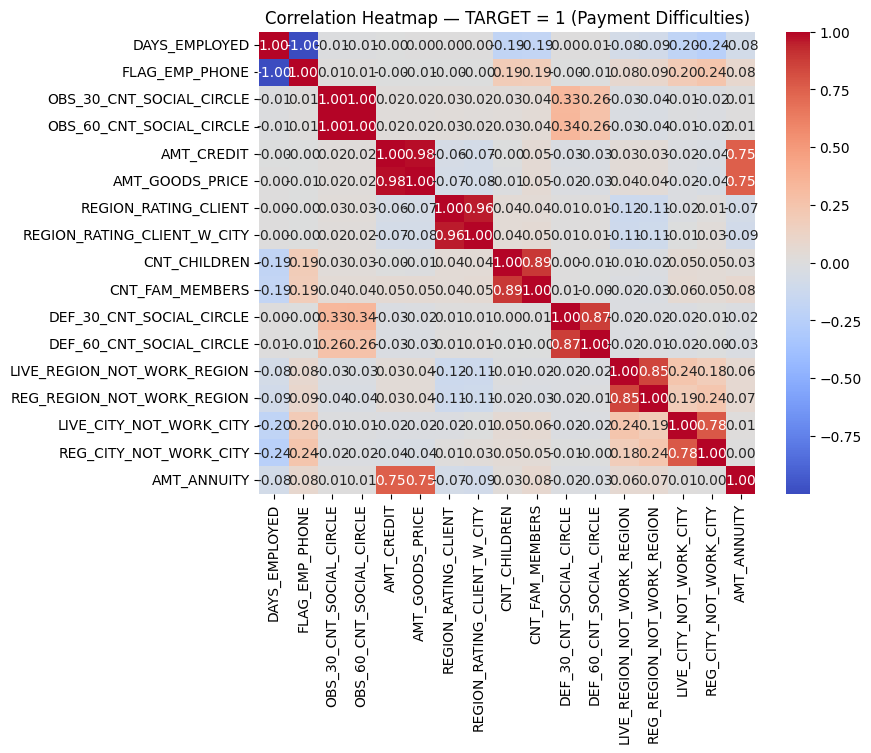

In [37]:
plt.figure(figsize=(8,6))
sns.heatmap(
    d1[vars1].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap — TARGET = 1 (Payment Difficulties)")
plt.show()

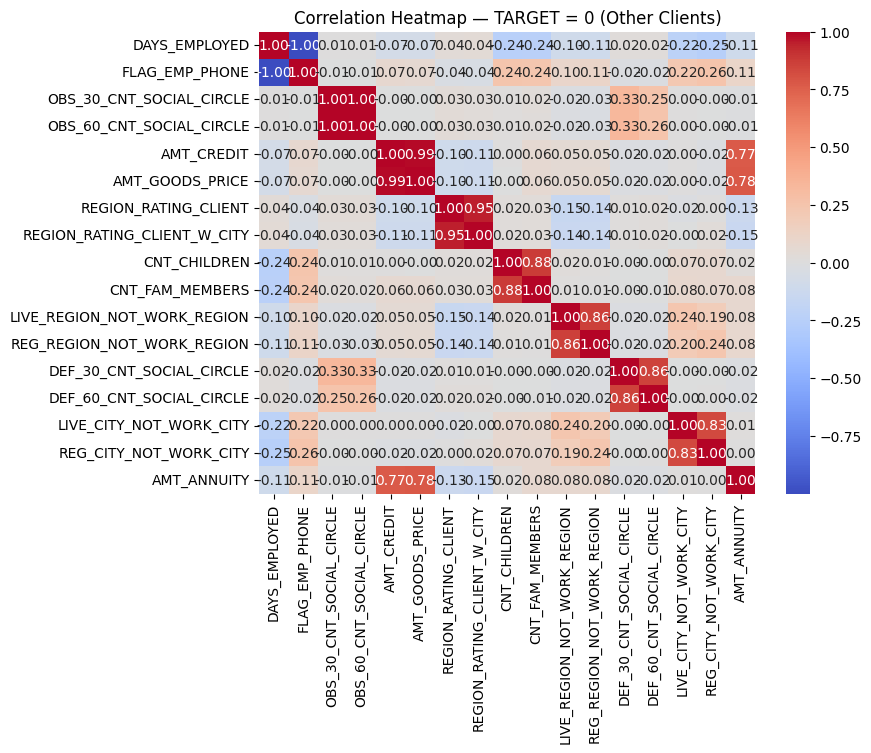

In [38]:
plt.figure(figsize=(8,6))
sns.heatmap(
    d0[vars0].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap — TARGET = 0 (Other Clients)")
plt.show()

# Correlation heatmaps were generated separately for defaulting and non-defaulting customers.
# Strong correlations were observed among loan size variables (credit amount, annuity, and goods price).
# These relationships were more intense among clients with payment difficulties, suggesting loan structure and affordability play a major role in default behavior.